# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`: Arsalaan Alam**  
**`Roll Number`: U20340064**  
**`GitHub Branch`:** arsalaan_U20230064

# Imports and Setup

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from rlcmab_sampler import sampler


# Load Datasets

In [24]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(news_df.head())
print(train_users.head())


                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [25]:
# Data Preprocessing for User Classification

# Check missing values
print("Missing values in train_users:")
print(train_users.isnull().sum())
print(f"\nTotal rows: {len(train_users)}")

# Check unique values in label column
print(f"\nUser categories (labels): {train_users['label'].unique()}")

Missing values in train_users:
user_id                          0
age                            698
income                           0
clicks                           0
purchase_amount                  0
session_duration                 0
content_variety                  0
engagement_score                 0
num_transactions                 0
avg_monthly_spend                0
avg_cart_value                   0
browsing_depth                   0
revisit_rate                     0
scroll_activity                  0
time_on_site                     0
interaction_count                0
preferred_price_range            0
discount_usage_rate              0
wishlist_size                    0
product_views                    0
repeat_purchase_gap (days)       0
churn_risk_score                 0
loyalty_index                    0
screen_brightness                0
battery_percentage               0
cart_abandonment_count           0
browser_version                  0
background_app_count    

## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


In [26]:

df = train_users.copy()
df = df.drop(columns=['user_id'])
df['age'] = df['age'].fillna(df['age'].median())

# Encode categorical features
label_encoders = {}

# Encode region_code
le_region = LabelEncoder()
df['region_code'] = le_region.fit_transform(df['region_code'])
label_encoders['region_code'] = le_region

# Encode browser_version
le_browser = LabelEncoder()
df['browser_version'] = le_browser.fit_transform(df['browser_version'])
label_encoders['browser_version'] = le_browser

# Encode subscriber (boolean to int)
df['subscriber'] = df['subscriber'].astype(int)

# Separate features and target
X = df.drop(columns=['label'])
y = df['label']

# Encode target labels
le_label = LabelEncoder()
y_encoded = le_label.fit_transform(y)
label_encoders['label'] = le_label

print(f"Features shape: {X.shape}")
print(f"Target classes: {le_label.classes_}")

Features shape: (2000, 31)
Target classes: ['user_1' 'user_2' 'user_3']


In [27]:
# Split into training (80%) and validation (20%) sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")

Training set size: 1600
Validation set size: 400


In [28]:
# Scale features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Use Voting Ensemble (combines multiple classifiers)
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression

print("Training Voting Ensemble Classifier...")

# Create ensemble of multiple classifiers
rf = RandomForestClassifier(n_estimators=500, max_depth=None, random_state=42, n_jobs=-1)
gb = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)

clf = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('lr', lr)],
    voting='soft',
    n_jobs=-1
)
clf.fit(X_train_scaled, y_train)

# Predict on validation set
y_pred = clf.predict(X_val_scaled)

# Evaluate the classifier
print("\nClassification Report on Validation Set:\n")
print(classification_report(y_val, y_pred, target_names=le_label.classes_))

# Also print accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {accuracy:.4f}")

Training Voting Ensemble Classifier...

Classification Report on Validation Set:

              precision    recall  f1-score   support

      user_1       0.89      0.87      0.88       142
      user_2       1.00      0.88      0.94       142
      user_3       0.84      0.99      0.91       116

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400

Validation Accuracy: 0.9075


# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

In [29]:
# Roll number for sampler (use last 2-3 digits of your roll, e.g. U202300064 -> 64)
ROLL_NUMBER = 64
reward_sampler = sampler(ROLL_NUMBER)

# Bandit constants: 3 contexts (user_1, user_2, user_3), 4 arms per context (Entertainment, Education, Tech, Crime)
NUM_CONTEXTS = 3
ARMS_PER_CONTEXT = 4
NUM_ARMS = 12
NEWS_CATEGORIES = ['Entertainment', 'Education', 'Tech', 'Crime']

def context_to_arm_index(context_id, arm_in_context):
    """Map (context_id, arm_in_context) to global arm index j in [0, 11]."""
    return context_id * ARMS_PER_CONTEXT + arm_in_context

def sample_reward(j):
    """Get reward for arm j from the environment."""
    return reward_sampler.sample(j)

## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [30]:
def run_epsilon_greedy(epsilon, T, reward_sampler, seed=42):
    """Run epsilon-greedy for T steps. Returns per-context Q, N, and reward history for each context."""
    rng = np.random.default_rng(seed)
    # For each context: Q[c][a], N[c][a]
    Q = [np.zeros(ARMS_PER_CONTEXT) for _ in range(NUM_CONTEXTS)]
    N = [np.zeros(ARMS_PER_CONTEXT, dtype=int) for _ in range(NUM_CONTEXTS)]
    rewards_by_context = {c: [] for c in range(NUM_CONTEXTS)}
    
    for t in range(T):
        # Random context (uniform over 3 contexts for simulation)
        c = rng.integers(0, NUM_CONTEXTS)
        if rng.random() < epsilon:
            a = rng.integers(0, ARMS_PER_CONTEXT)
        else:
            a = int(np.argmax(Q[c]))
        j = context_to_arm_index(c, a)
        r = reward_sampler.sample(j)
        rewards_by_context[c].append(r)
        N[c][a] += 1
        Q[c][a] += (r - Q[c][a]) / N[c][a]
    
    return Q, N, rewards_by_context

## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [31]:
def run_ucb(C, T, reward_sampler, seed=42):
    """Run UCB with exploration parameter C for T steps."""
    rng = np.random.default_rng(seed)
    Q = [np.zeros(ARMS_PER_CONTEXT) for _ in range(NUM_CONTEXTS)]
    N = [np.zeros(ARMS_PER_CONTEXT, dtype=int) for _ in range(NUM_CONTEXTS)]
    rewards_by_context = {c: [] for c in range(NUM_CONTEXTS)}
    
    for t in range(T):
        c = rng.integers(0, NUM_CONTEXTS)
        # UCB: a = argmax_a [ Q(a) + C * sqrt(ln(t+1) / N(a)) ]
        n_total = N[c].sum()
        if n_total == 0 or (N[c] == 0).any():
            a = int(np.argmax(N[c] == 0)) if (N[c] == 0).any() else rng.integers(0, ARMS_PER_CONTEXT)
        else:
            ucb = Q[c] + C * np.sqrt(np.log(n_total + 1) / (N[c] + 1e-8))
            a = int(np.argmax(ucb))
        j = context_to_arm_index(c, a)
        r = reward_sampler.sample(j)
        rewards_by_context[c].append(r)
        N[c][a] += 1
        Q[c][a] += (r - Q[c][a]) / N[c][a]
    
    return Q, N, rewards_by_context

## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


In [32]:
def run_softmax(tau, T, reward_sampler, seed=42):
    """Run SoftMax with temperature τ for T steps. Returns Q, N, and reward history per context."""
    rng = np.random.default_rng(seed)
    Q = [np.zeros(ARMS_PER_CONTEXT) for _ in range(NUM_CONTEXTS)]
    N = [np.zeros(ARMS_PER_CONTEXT, dtype=int) for _ in range(NUM_CONTEXTS)]
    rewards_by_context = {c: [] for c in range(NUM_CONTEXTS)}
    
    for t in range(T):
        c = rng.integers(0, NUM_CONTEXTS)
        # SoftMax: P(a) ∝ exp(Q[a] / tau). Use numerical stability: subtract max.
        q = Q[c]
        exp_q = np.exp((q - q.max()) / tau)
        probs = exp_q / exp_q.sum()
        a = rng.choice(ARMS_PER_CONTEXT, p=probs)
        j = context_to_arm_index(c, a)
        r = reward_sampler.sample(j)
        rewards_by_context[c].append(r)
        N[c][a] += 1
        Q[c][a] += (r - Q[c][a]) / N[c][a]
    
    return Q, N, rewards_by_context

## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [33]:
T = 10_000  # Time horizon for RL simulation

# Epsilon-Greedy: test at least 3 values of ε
epsilons = [0.1, 0.2, 0.3]
eg_results = {}
for eps in epsilons:
    Q, N, rewards_by_context = run_epsilon_greedy(eps, T, reward_sampler)
    eg_results[eps] = {'Q': Q, 'N': N, 'rewards_by_context': rewards_by_context}

# UCB: test at least 3 values of C
C_values = [0.5, 1.0, 2.0]
ucb_results = {}
for C in C_values:
    Q, N, rewards_by_context = run_ucb(C, T, reward_sampler)
    ucb_results[C] = {'Q': Q, 'N': N, 'rewards_by_context': rewards_by_context}

# SoftMax: τ = 1
tau = 1.0
sm_Q, sm_N, sm_rewards_by_context = run_softmax(tau, T, reward_sampler)
softmax_result = {'Q': sm_Q, 'N': sm_N, 'rewards_by_context': sm_rewards_by_context}

print("Simulation complete. Epsilon-Greedy (ε), UCB (C), and SoftMax (τ=1) runs stored.")

Simulation complete. Epsilon-Greedy (ε), UCB (C), and SoftMax (τ=1) runs stored.


## Recommendation Engine

End-to-end workflow:
1. **Classify:** Predict user category (context) using the classifier from §5.2.
2. **Select Category:** Use the trained bandit policy (Q) to choose the best news category for that context.
3. **Recommend:** Sample one article from `news_articles.csv` in the selected category.
Input: user features from `test_users.csv`. Output: predicted category + one sampled article.

In [34]:
# Map raw news_articles category to bandit categories (Entertainment, Education, Tech, Crime)
def map_article_category(raw_cat):
    raw_upper = str(raw_cat).upper()
    if raw_upper in ('ENTERTAINMENT', 'COMEDY', 'ARTS & CULTURE', 'PARENTING', 'PARENTS', 'WEIRD NEWS', 'CULTURE & ARTS'):
        return 'Entertainment'
    if raw_upper in ('EDUCATION', 'COLLEGE', 'HEALTHY LIVING', 'LIFESTYLE', 'WORLD NEWS', 'THE WORLDPOST', 'WORLDPOST'):
        return 'Education'
    if raw_upper in ('TECH', 'TECHNOLOGY', 'SCIENCE', 'GREEN', 'ENVIRONMENT', 'BUSINESS'):
        return 'Tech'
    if raw_upper in ('CRIME', 'U.S. NEWS', 'POLITICS', 'BLACK VOICES', 'LATINO VOICES', 'MEDIA'):
        return 'Crime'
    return 'Entertainment'  # default

news_df['mapped_category'] = news_df['category'].apply(map_article_category)
articles_by_category = {cat: news_df[news_df['mapped_category'] == cat].index.tolist() for cat in NEWS_CATEGORIES}

def preprocess_user(user_df, label_encoders):
    df = user_df.copy()
    df = df.drop(columns=['user_id'], errors='ignore')
    df['age'] = df['age'].fillna(train_users['age'].median())
    # Handle unseen labels: use first known class
    le_r = label_encoders['region_code']
    df['region_code'] = df['region_code'].apply(lambda x: x if x in le_r.classes_ else le_r.classes_[0])
    df['region_code'] = le_r.transform(df['region_code'])
    le_b = label_encoders['browser_version']
    df['browser_version'] = df['browser_version'].apply(lambda x: x if x in le_b.classes_ else le_b.classes_[0])
    df['browser_version'] = le_b.transform(df['browser_version'])
    df['subscriber'] = df['subscriber'].astype(int)
    return df

def predict_context(user_features):
    X_scaled = scaler.transform(user_features)
    pred = clf.predict(X_scaled)
    return le_label.inverse_transform(pred)  # e.g. 'user_1'

# Use trained bandit policy (epsilon-greedy with ε=0.1) to select best category per context
policy_Q = eg_results[0.1]['Q']
context_to_id = {'user_1': 0, 'user_2': 1, 'user_3': 2}

def recommend_for_user(user_row, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    user_df = pd.DataFrame([user_row])
    feats = preprocess_user(user_df, label_encoders)
    contexts = predict_context(feats)
    context_name = contexts[0]
    c = context_to_id[context_name]
    best_arm = int(np.argmax(policy_Q[c]))
    category_name = NEWS_CATEGORIES[best_arm]
    indices = articles_by_category.get(category_name, news_df.index.tolist())
    idx = rng.choice(indices)
    article = news_df.loc[idx, ['headline', 'category', 'link']].to_dict()
    return context_name, category_name, article

# Demo: recommend for first 3 test users
rng = np.random.default_rng(42)
print("Recommendation Engine demo (first 3 test users):\n")
for i in range(3):
    row = test_users.iloc[i]
    ctx, cat, art = recommend_for_user(row, rng)
    print(f"User {row['user_id']}: predicted context={ctx}, category={cat}")
    print(f"  Article: {art['headline'][:60]}...")
    print()

Recommendation Engine demo (first 3 test users):

User U4058: predicted context=user_2, category=Crime
  Article: Chuck Schumer To Introduce Resolution To Name Senate Buildin...

User U1118: predicted context=user_1, category=Tech
  Article: Alien Space Probes? Physics Paper Considers Craft Other Bein...

User U6555: predicted context=user_2, category=Crime
  Article: The GOP Candidates Are Just A Bunch Of Immature Middle Schoo...



## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


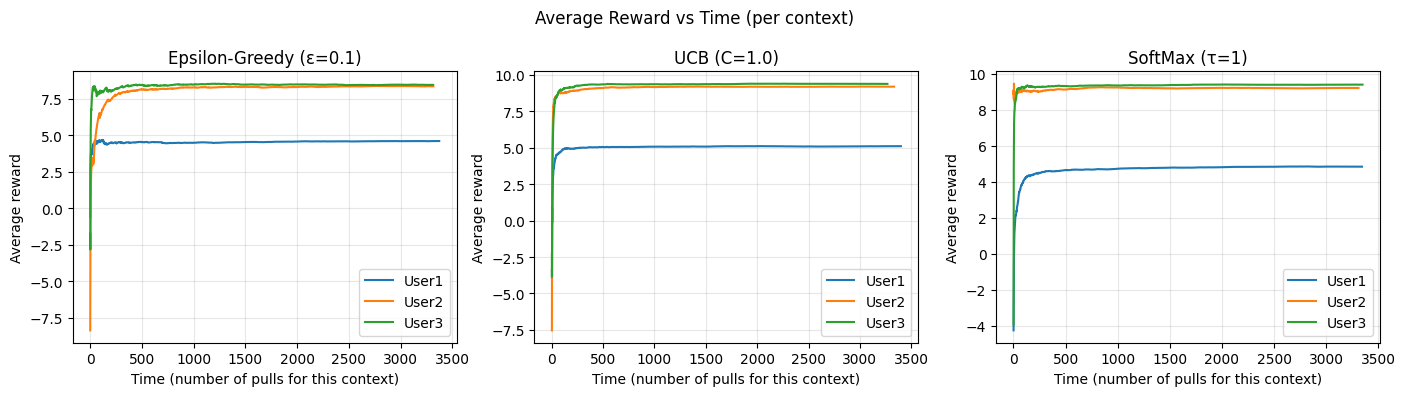

In [35]:
# Helper: cumulative average reward over time for a list of rewards
def cumavg(rewards):
    r = np.array(rewards, dtype=float)
    return np.cumsum(r) / np.arange(1, len(r) + 1)

# --- Plot 1: Average Reward vs Time for each context (one figure per algorithm) ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
context_names = ['User1', 'User2', 'User3']

# Epsilon-Greedy (ε=0.1)
for c in range(NUM_CONTEXTS):
    r = eg_results[0.1]['rewards_by_context'][c]
    if len(r) > 0:
        axes[0].plot(np.arange(1, len(r)+1), cumavg(r), label=context_names[c])
axes[0].set_xlabel('Time (number of pulls for this context)')
axes[0].set_ylabel('Average reward')
axes[0].set_title('Epsilon-Greedy (ε=0.1)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# UCB (C=1.0)
for c in range(NUM_CONTEXTS):
    r = ucb_results[1.0]['rewards_by_context'][c]
    if len(r) > 0:
        axes[1].plot(np.arange(1, len(r)+1), cumavg(r), label=context_names[c])
axes[1].set_xlabel('Time (number of pulls for this context)')
axes[1].set_ylabel('Average reward')
axes[1].set_title('UCB (C=1.0)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# SoftMax (τ=1)
for c in range(NUM_CONTEXTS):
    r = softmax_result['rewards_by_context'][c]
    if len(r) > 0:
        axes[2].plot(np.arange(1, len(r)+1), cumavg(r), label=context_names[c])
axes[2].set_xlabel('Time (number of pulls for this context)')
axes[2].set_ylabel('Average reward')
axes[2].set_title('SoftMax (τ=1)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Average Reward vs Time (per context)', fontsize=12)
plt.tight_layout()
plt.show()

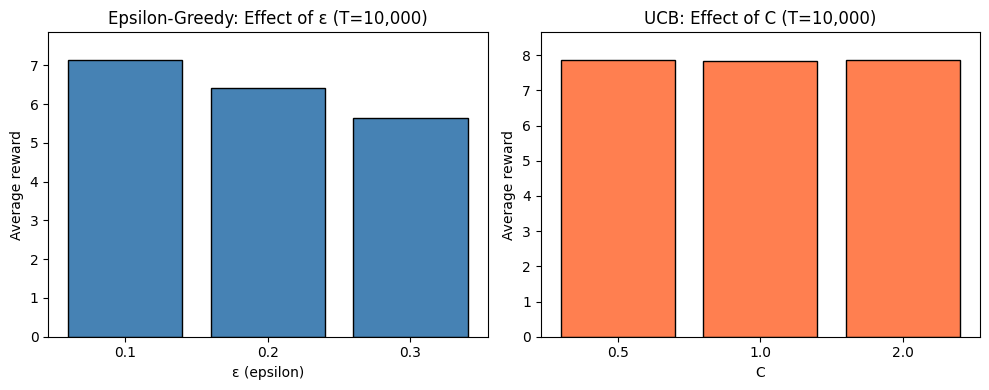

Expected reward (final Q) per arm, Epsilon-Greedy ε=0.1:
  Context User1: [-1.96117329 -4.37251681  5.0870619   2.79075526]
  Context User2: [-8.44363097 -1.26091833  4.77062736  9.19158054]
  Context User3: [-2.01043449 -3.49611169  9.38519921 -4.26353842]

Expected reward (final Q) per arm, UCB C=1.0:
  Context User1: [-3.39605615 -4.58487199  5.09910548  1.30196148]
  Context User2: [-7.52750994  0.41995832  5.71632294  9.17950575]
  Context User3: [-2.33314176 -5.38569056  9.37234389 -3.17834302]

Expected reward (final Q) per arm, SoftMax τ=1:
  Context User1: [-1.70950531 -4.2466534   5.08338322  2.75764847]
  Context User2: [-8.79114181  0.          0.          9.21052192]
  Context User3: [ 0.         -4.90570231  9.39936607 -3.92361372]


In [36]:
# --- Plot 2: Average Reward comparison for different ε and C ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Epsilon-Greedy: mean reward vs ε
eg_means = [np.concatenate(list(eg_results[eps]['rewards_by_context'].values())).mean() for eps in epsilons]
ax1.bar([str(e) for e in epsilons], eg_means, color='steelblue', edgecolor='black')
ax1.set_xlabel('ε (epsilon)')
ax1.set_ylabel('Average reward')
ax1.set_title('Epsilon-Greedy: Effect of ε (T=10,000)')
ax1.set_ylim(0, max(eg_means) * 1.1)

# UCB: mean reward vs C
ucb_means = [np.concatenate(list(ucb_results[C]['rewards_by_context'].values())).mean() for C in C_values]
ax2.bar([str(c) for c in C_values], ucb_means, color='coral', edgecolor='black')
ax2.set_xlabel('C')
ax2.set_ylabel('Average reward')
ax2.set_title('UCB: Effect of C (T=10,000)')
ax2.set_ylim(0, max(ucb_means) * 1.1)

plt.tight_layout()
plt.show()

# Expected reward distribution (final Q) for best configs
print("Expected reward (final Q) per arm, Epsilon-Greedy ε=0.1:")
for c in range(NUM_CONTEXTS):
    print(f"  Context {context_names[c]}: {eg_results[0.1]['Q'][c]}")
print("\nExpected reward (final Q) per arm, UCB C=1.0:")
for c in range(NUM_CONTEXTS):
    print(f"  Context {context_names[c]}: {ucb_results[1.0]['Q'][c]}")
print("\nExpected reward (final Q) per arm, SoftMax τ=1:")
for c in range(NUM_CONTEXTS):
    print(f"  Context {context_names[c]}: {softmax_result['Q'][c]}")

## Final Observations

The full report is in **README.md** at the repository root.
